# Scheduler campaign metrics

Input tables are produced by `query_sim/metrics.py` under `outputs_query/scheduler_campaign/`.

Figures are written under `figures/selected/scheduler_campaign/`.

Palette:

- Enterprise: `#CC79A7`
- Premium: `#E69F00`
- Freemium: `#0D7D87`
- Dark gray: `#5F6B73`
- Light gray: `#C9CFD6`


In [1]:
from pathlib import Path
from matplotlib.patches import Patch
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

ROOT = Path.cwd()
if not (ROOT / "query_sim").exists() and (ROOT.parent / "query_sim").exists():
    ROOT = ROOT.parent

PREFERRED_CAMPAIGN = "scheduler_campaign_dense_T2000"
CAMPAIGN_DIR = ROOT / "outputs_query" / PREFERRED_CAMPAIGN
if not CAMPAIGN_DIR.exists():
    CAMPAIGN_DIR = ROOT / "outputs_query" / "scheduler_campaign"

PREFERRED_RATIO_CAMPAIGN = "scheduler_campaign_ratios_T1800"
RATIO_CAMPAIGN_DIR = ROOT / "outputs_query" / PREFERRED_RATIO_CAMPAIGN
SENSITIVITY_CAMPAIGN_DIR = RATIO_CAMPAIGN_DIR if RATIO_CAMPAIGN_DIR.exists() else CAMPAIGN_DIR

SELECTED_RATIO = "balanced"
MAX_MAIN_T = 1800

# Line-marker controls
USE_LINE_MARKERS = False
LINE_MARK_EVERY = 1
LINE_MARKER_SCALE = 1.0

FIG_DIR = ROOT / "figures" / "selected" / "scheduler_campaign"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root:", ROOT)
print("Detailed campaign directory:", CAMPAIGN_DIR)
print("Ratio-sensitivity campaign directory:", SENSITIVITY_CAMPAIGN_DIR)
print("Detailed ratio:", SELECTED_RATIO)
print("Main plot range: T <=", MAX_MAIN_T)
print("Line markers:", "enabled" if USE_LINE_MARKERS else "disabled")
print("Figure directory:", FIG_DIR)


Repository root: /home/spirals/phd/experiments/plb_batsim
Detailed campaign directory: /home/spirals/phd/experiments/plb_batsim/outputs_query/scheduler_campaign_dense_T2000
Ratio-sensitivity campaign directory: /home/spirals/phd/experiments/plb_batsim/outputs_query/scheduler_campaign_ratios_T1800
Detailed ratio: balanced
Main plot range: T <= 1800
Line markers: disabled
Figure directory: /home/spirals/phd/experiments/plb_batsim/figures/selected/scheduler_campaign


## Plot style

Figure sizes follow common conference-paper layouts:

- single column: 3.35 inches wide
- double column: 6.90 inches wide

Figures are saved as PDF only.

Line markers are controlled from the first configuration cell through `USE_LINE_MARKERS`, `LINE_MARK_EVERY`, and `LINE_MARKER_SCALE`.


In [2]:
PALETTE = {
    "freemium": "#0D7D87",
    "premium": "#E69F00",
    "enterprise": "#CC79A7",
    "dark_gray": "#5F6B73",
    "light_gray": "#C9CFD6",
    "mid_gray": "#8A949B",
    "black": "#222222",
}

CLASS_ORDER = ["enterprise", "premium", "freemium"]
CLASS_LABELS = {
    "enterprise": "Enterprise",
    "premium": "Premium",
    "freemium": "Freemium",
    "overall": "Overall",
}

RATIO_ORDER = [
    "balanced",
    "enterprise_heavy",
    "premium_heavy",
    "freemium_heavy",
]
RATIO_LABELS = {
    "balanced": "1:1:1",
    "enterprise_heavy": "3:1:1",
    "premium_heavy": "1:3:1",
    "freemium_heavy": "1:1:3",
}
RATIO_STYLE = {
    "balanced": {
        "color": PALETTE["black"], "linewidth": 1.5, "linestyle": "-",
        "marker": "o", "markersize": 3.0,
    },
    "enterprise_heavy": {
        "color": PALETTE["enterprise"], "linewidth": 1.3, "linestyle": "-",
        "marker": "s", "markersize": 2.7, "markerfacecolor": "none",
    },
    "premium_heavy": {
        "color": PALETTE["premium"], "linewidth": 1.3, "linestyle": "-",
        "marker": "^", "markersize": 2.7, "markerfacecolor": "none",
    },
    "freemium_heavy": {
        "color": PALETTE["freemium"], "linewidth": 1.3, "linestyle": "-",
        "marker": "D", "markersize": 2.5, "markerfacecolor": "none",
    },
}

SCHEDULER_LABELS = {
    "plb_nclass": "PLB",
    "round_robin": "RR",
    "least_loaded": "LL",
    "static_6_1_1": "6+1+1",
    "static_5_2_1": "5+2+1",
    "static_4_3_1": "4+3+1",
    "static_4_2_2": "4+2+2",
}

MAIN_SCHEDULERS = ["round_robin", "least_loaded", "plb_nclass"]
STATIC_SCHEDULERS = ["static_6_1_1", "static_5_2_1", "static_4_3_1", "static_4_2_2"]
SCHEDULER_ORDER = MAIN_SCHEDULERS[:2] + STATIC_SCHEDULERS + ["plb_nclass"]

STATIC_SPLIT_COLORS = {
    "static_6_1_1": "#0072B2",
    "static_5_2_1": "#009E73",
    "static_4_3_1": "#D55E00",
    "static_4_2_2": "#7A3E9D",
}

SCHEDULER_STYLE = {
    "plb_nclass": {
        "color": PALETTE["black"], "linewidth": 2.0, "linestyle": "-",
        "marker": "o", "markersize": 3.0,
    },
    "round_robin": {
        "color": PALETTE["dark_gray"], "linewidth": 1.1, "linestyle": "--",
        "marker": "s", "markersize": 2.5, "markerfacecolor": "none",
    },
    "least_loaded": {
        "color": PALETTE["mid_gray"], "linewidth": 1.1, "linestyle": "-.",
        "marker": "^", "markersize": 2.5, "markerfacecolor": "none",
    },
    "static_6_1_1": {
        "color": STATIC_SPLIT_COLORS["static_6_1_1"], "linewidth": 1.15, "linestyle": "-",
        "marker": "v", "markersize": 2.4, "markerfacecolor": "none", "alpha": 0.90,
    },
    "static_5_2_1": {
        "color": STATIC_SPLIT_COLORS["static_5_2_1"], "linewidth": 1.15, "linestyle": "-",
        "marker": "D", "markersize": 2.4, "markerfacecolor": "none", "alpha": 0.90,
    },
    "static_4_3_1": {
        "color": STATIC_SPLIT_COLORS["static_4_3_1"], "linewidth": 1.15, "linestyle": "-",
        "marker": "P", "markersize": 2.4, "markerfacecolor": "none", "alpha": 0.90,
    },
    "static_4_2_2": {
        "color": STATIC_SPLIT_COLORS["static_4_2_2"], "linewidth": 1.15, "linestyle": "-",
        "marker": "X", "markersize": 2.4, "markerfacecolor": "none", "alpha": 0.90,
    },
}

MARKER_STYLE_KEYS = (
    "marker",
    "markersize",
    "markerfacecolor",
    "markeredgecolor",
    "markeredgewidth",
    "markevery",
)

def configure_marker_styles(style_map):
    for style in style_map.values():
        if USE_LINE_MARKERS:
            if "markersize" in style:
                style["markersize"] = style["markersize"] * LINE_MARKER_SCALE
            if LINE_MARK_EVERY is not None:
                style["markevery"] = LINE_MARK_EVERY
        else:
            for key in MARKER_STYLE_KEYS:
                style.pop(key, None)

configure_marker_styles(RATIO_STYLE)
configure_marker_styles(SCHEDULER_STYLE)

SINGLE_COL = (3.35, 2.25)
DOUBLE_COL = (6.90, 2.35)
DOUBLE_COL_TALL = (6.90, 3.10)
GRID_FIG = (6.90, 4.30)

plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "figure.titlesize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.45,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def scheduler_label(name):
    return SCHEDULER_LABELS.get(name, name)

def ratio_label(name):
    return RATIO_LABELS.get(name, name.replace("_", " "))

def available_ratio_order(table):
    if "ratio" not in table.columns:
        return []
    present = set(table["ratio"].dropna().unique())
    ordered = [r for r in RATIO_ORDER if r in present]
    ordered.extend(sorted(present - set(ordered)))
    return ordered

def static_replicas_for_class(scheduler, class_name):
    if not scheduler.startswith("static_"):
        return np.nan
    parts = [int(x) for x in scheduler.replace("static_", "").split("_")]
    index = CLASS_ORDER.index(class_name)
    return parts[index]

def scheduler_label_for_class(name, class_name=None):
    return scheduler_label(name)

def save_figure(fig, name):
    pdf = FIG_DIR / f"{name}.pdf"
    png = FIG_DIR / f"{name}.png"
    if png.exists():
        png.unlink()
    fig.savefig(pdf)
    print("saved", pdf.relative_to(ROOT))


## Load metric tables

This section loads the analyzer output tables.


In [3]:
required_files = {
    "latency": "class_latency_metrics.csv",
    "concurrency": "class_concurrency_metrics.csv",
    "support": "calibration_support_metrics.csv",
    "composition": "replica_composition_metrics.csv",
    "concentration": "class_concentration_metrics.csv",
    "decision": "decision_metrics.csv",
    "baseline_comparison": "baseline_comparison_metrics.csv",
}

def load_metric_tables(campaign_dir):
    missing = [name for name in required_files.values() if not (campaign_dir / name).exists()]
    if missing:
        raise FileNotFoundError(
            "Missing campaign metric files under "
            + str(campaign_dir)
            + ": "
            + ", ".join(missing)
        )

    return {
        key: pd.read_csv(campaign_dir / filename)
        for key, filename in required_files.items()
    }

detailed_tables = load_metric_tables(CAMPAIGN_DIR)
sensitivity_tables = load_metric_tables(SENSITIVITY_CAMPAIGN_DIR)

latency = detailed_tables["latency"]
concurrency = detailed_tables["concurrency"]
support = detailed_tables["support"]
composition = detailed_tables["composition"]
concentration = detailed_tables["concentration"]
decision = detailed_tables["decision"]
baseline_cmp = detailed_tables["baseline_comparison"]

latency_for_sensitivity = sensitivity_tables["latency"]
concurrency_for_sensitivity = sensitivity_tables["concurrency"]
support_for_sensitivity = sensitivity_tables["support"]
composition_for_sensitivity = sensitivity_tables["composition"]
concentration_for_sensitivity = sensitivity_tables["concentration"]
decision_for_sensitivity = sensitivity_tables["decision"]
baseline_cmp_for_sensitivity = sensitivity_tables["baseline_comparison"]

def main_range(df, max_T=MAX_MAIN_T):
    if "T" not in df.columns:
        return df.copy()
    return df[df["T"] <= max_T].copy()

def detailed_range(df, ratio=SELECTED_RATIO, max_T=MAX_MAIN_T):
    out = main_range(df, max_T=max_T)
    if "ratio" in out.columns:
        out = out[out["ratio"] == ratio].copy()
    return out

latency_main = detailed_range(latency)
concurrency_main = detailed_range(concurrency)
support_main = detailed_range(support)
composition_main = detailed_range(composition)
concentration_main = detailed_range(concentration)
decision_main = detailed_range(decision)
baseline_cmp_main = detailed_range(baseline_cmp)

latency_sensitivity = main_range(latency_for_sensitivity)
concurrency_sensitivity = main_range(concurrency_for_sensitivity)
support_sensitivity = main_range(support_for_sensitivity)
composition_sensitivity = main_range(composition_for_sensitivity)
concentration_sensitivity = main_range(concentration_for_sensitivity)
decision_sensitivity = main_range(decision_for_sensitivity)
baseline_cmp_sensitivity = main_range(baseline_cmp_for_sensitivity)

print("Detailed campaign:", CAMPAIGN_DIR)
print("Sensitivity campaign:", SENSITIVITY_CAMPAIGN_DIR)

print("latency", latency.shape, "detailed", latency_main.shape, "sensitivity", latency_sensitivity.shape)
print("concurrency", concurrency.shape, "detailed", concurrency_main.shape, "sensitivity", concurrency_sensitivity.shape)
print("support", support.shape, "detailed", support_main.shape, "sensitivity", support_sensitivity.shape)
print("composition", composition.shape, "detailed", composition_main.shape, "sensitivity", composition_sensitivity.shape)
print("concentration", concentration.shape, "detailed", concentration_main.shape, "sensitivity", concentration_sensitivity.shape)
print("decision", decision.shape, "detailed", decision_main.shape, "sensitivity", decision_sensitivity.shape)
print("baseline comparison", baseline_cmp.shape, "detailed", baseline_cmp_main.shape, "sensitivity", baseline_cmp_sensitivity.shape)

print("Detailed schedulers:", sorted(latency["scheduler"].unique()))
print("Detailed ratios:", available_ratio_order(latency))
print("Sensitivity ratios:", available_ratio_order(latency_sensitivity))
print("Detailed T levels:", sorted(latency["T"].unique()))
print("Sensitivity T levels:", sorted(latency_sensitivity["T"].unique()))


Detailed campaign: /home/spirals/phd/experiments/plb_batsim/outputs_query/scheduler_campaign_dense_T2000
Sensitivity campaign: /home/spirals/phd/experiments/plb_batsim/outputs_query/scheduler_campaign_ratios_T1800
latency (792, 13) detailed (748, 13) sensitivity (1904, 13)
concurrency (792, 12) detailed (748, 12) sensitivity (1904, 12)
support (792, 10) detailed (748, 10) sensitivity (1904, 10)
composition (1584, 16) detailed (1496, 16) sensitivity (3808, 16)
concentration (594, 11) detailed (561, 11) sensitivity (1428, 11)
decision (198, 25) detailed (187, 25) sensitivity (476, 25)
baseline comparison (4320, 16) detailed (4080, 16) sensitivity (3264, 16)
Detailed schedulers: ['global_target_repair_neutral', 'global_target_repair_neutral_init_4_2_2', 'global_target_repair_target_only', 'global_target_repair_target_only_init_4_2_2', 'least_loaded', 'plb_nclass', 'round_robin', 'static_4_2_2', 'static_4_3_1', 'static_5_2_1', 'static_6_1_1']
Detailed ratios: ['balanced']
Sensitivity ratio

## Metric definitions

For scheduler $p$, priority class $c$, pressure level $T$, and latency quantile $q$:

$$
L_q(p,c,T)=Q_q\left(\{\ell_i \mid class_i=c,\ p_i=p,\ T_i=T\}\right)
$$

where $\ell_i$ is the simulated Q1 latency of query $i$.

Overall Q1 latency pools all queries from the run:

$$
L_q(p,overall,T)=Q_q\left(\{\ell_i \mid p_i=p,\ T_i=T\}\right)
$$

Local Q1 concurrency at start is summarized as:

$$
C_q(p,c,T)=Q_q\left(\{x_i \mid class_i=c,\ p_i=p,\ T_i=T\}\right)
$$

where $x_i$ is the number of already-running Q1 queries on the selected replica when query $i$ starts.

Priority-ordering violations are summarized by:

$$
G_q(p,T)=\max(0,L_q(p,enterprise,T)-L_q(p,premium,T)) +
\max(0,L_q(p,premium,T)-L_q(p,freemium,T))
$$

A value of zero means that the measured latency ordering is consistent with the priority order.

For replica-concentration metrics, let $A_{r,c}$ be the time integral of active Q1 queries of class $c$ on replica $r$. Then:

$$
share_{r,c}=\frac{A_{r,c}}{\sum_j A_{j,c}},\qquad
HHI_c=\sum_r share_{r,c}^2,\qquad
effective\_replicas_c=\frac{1}{HHI_c}
$$

For PLB-to-baseline comparisons:

$$
ratio_q(c,b,T)=\frac{L_q(PLB,c,T)}{L_q(b,c,T)}
$$

Dedicated static splits are plotted as simulated runs. No averaging is applied across different static split names, even when two splits assign the same number of replicas to a class.


## Calibration-support check

The empirical Q1 latency model is calibrated only for local Q1 concurrency values observed in the BenchBase Q1 calibration data. Main latency figures below use only terminal pressures for which query-start concurrency remains inside that empirical support.


In [4]:
calibration_path = ROOT / "data" / "calibration" / "q1_query_observations.csv"
calibration_df = pd.read_csv(calibration_path)
SUPPORT_MAX = int(calibration_df["in_flight_queries"].max())

def load_query_events(campaign_dir):
    frames = []
    for path in sorted(campaign_dir.rglob("query_events.csv")):
        scheduler = path.parent.name
        seed = int(path.parent.parent.name.replace("seed", ""))
        ratio = path.parent.parent.parent.name.replace("ratio_", "")
        T = int(path.parent.parent.parent.parent.name.replace("T", ""))

        df = pd.read_csv(path)
        df["scheduler"] = scheduler
        df["seed"] = seed
        df["ratio"] = ratio
        df["T"] = T
        frames.append(df)

    if not frames:
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)

query_events_all = load_query_events(SENSITIVITY_CAMPAIGN_DIR)

if query_events_all.empty:
    print("No query_events.csv files found under", SENSITIVITY_CAMPAIGN_DIR)
else:
    if "q1_start_concurrency" not in query_events_all.columns and "in_flight_at_start" in query_events_all.columns:
        query_events_all["q1_start_concurrency"] = query_events_all["in_flight_at_start"]

    query_events_all = query_events_all[
        query_events_all["class"].isin(CLASS_ORDER)
    ].copy()

    query_events_all["outside_calibration_support"] = (
        query_events_all["q1_start_concurrency"] > SUPPORT_MAX
    )

    support_by_ratio_T = (
        query_events_all
        .groupby(["ratio", "T"], as_index=False)
        .agg(
            queries=("q1_start_concurrency", "size"),
            max_q1_start_concurrency=("q1_start_concurrency", "max"),
            outside_support_queries=("outside_calibration_support", "sum"),
            outside_support_fraction=("outside_calibration_support", "mean"),
        )
        .sort_values(["ratio", "T"])
    )
    support_by_ratio_T["main_plot_range"] = support_by_ratio_T["T"] <= MAX_MAIN_T
    support_by_ratio_T["ratio_label"] = support_by_ratio_T["ratio"].map(ratio_label)

    support_violations = (
        query_events_all
        .groupby(["ratio", "scheduler", "T", "class"], as_index=False)
        .agg(
            queries=("q1_start_concurrency", "size"),
            max_q1_start_concurrency=("q1_start_concurrency", "max"),
            outside_support_queries=("outside_calibration_support", "sum"),
            outside_support_fraction=("outside_calibration_support", "mean"),
        )
    )

    support_violations = support_violations[
        support_violations["outside_support_queries"] > 0
    ].sort_values(
        ["ratio", "T", "outside_support_fraction", "max_q1_start_concurrency"],
        ascending=[True, True, False, False],
    )

    print("Calibration-support event source:", SENSITIVITY_CAMPAIGN_DIR)
    print("Calibration support max:", SUPPORT_MAX)
    print("Main plots use T <=", MAX_MAIN_T)

    display(
        support_by_ratio_T[
            [
                "ratio", "ratio_label", "T", "queries",
                "max_q1_start_concurrency", "outside_support_queries",
                "outside_support_fraction", "main_plot_range",
            ]
        ].reset_index(drop=True)
    )
    display(support_violations.reset_index(drop=True))


Calibration-support event source: /home/spirals/phd/experiments/plb_batsim/outputs_query/scheduler_campaign_ratios_T1800
Calibration support max: 599
Main plots use T <= 1800


,ratio,ratio_label,T,queries,max_q1_start_concurrency,outside_support_queries,outside_support_fraction,main_plot_range
0,balanced,1:1:1,120,840,30,0,0.000000,True
1,balanced,1:1:1,180,1260,53,0,0.000000,True
2,balanced,1:1:1,240,1680,72,0,0.000000,True
3,balanced,1:1:1,300,2100,89,0,0.000000,True
4,balanced,1:1:1,360,2520,112,0,0.000000,True
...,...,...,...,...,...,...,...,...
63,premium_heavy,1:3:1,1000,7000,589,0,0.000000,True
64,premium_heavy,1:3:1,1200,8400,707,109,0.012976,True
65,premium_heavy,1:3:1,1400,9800,826,231,0.023571,True
66,premium_heavy,1:3:1,1600,11200,945,349,0.031161,True


,ratio,scheduler,T,class,queries,max_q1_start_concurrency,outside_support_queries,outside_support_fraction
0,freemium_heavy,static_6_1_1,1200,freemium,720,708,109,0.151389
1,freemium_heavy,static_4_3_1,1200,freemium,720,706,107,0.148611
2,freemium_heavy,static_5_2_1,1200,freemium,720,704,105,0.145833
3,freemium_heavy,static_5_2_1,1400,freemium,840,828,231,0.275000
4,freemium_heavy,static_4_3_1,1400,freemium,840,827,230,0.273810
5,freemium_heavy,static_6_1_1,1400,freemium,840,825,229,0.272619
6,freemium_heavy,static_5_2_1,1600,freemium,960,951,354,0.368750
7,freemium_heavy,static_6_1_1,1600,freemium,960,948,353,0.367708
8,freemium_heavy,static_4_3_1,1600,freemium,960,948,352,0.366667
9,freemium_heavy,static_5_2_1,1800,freemium,1080,1068,474,0.438889


## Dedicated partition routing check

Representative routing check for `K=8`, `T=600`, balanced classes, seed 42.


In [5]:
run_root = CAMPAIGN_DIR / "K8" / "T600" / "ratio_balanced" / "seed42"

static_schedulers = ["static_6_1_1", "static_5_2_1", "static_4_3_1", "static_4_2_2"]

if run_root.exists():
    for sched in static_schedulers:
        path = run_root / sched / "query_events.csv"
        if path.exists():
            df = pd.read_csv(path)
            print("\n==", sched, "==")
            print(df.groupby("class")["replica"].apply(lambda s: sorted(set(map(int, s)))).to_string())
        else:
            print("Missing:", path)
else:
    print("Representative run folder not found:", run_root)



== static_6_1_1 ==
class
enterprise    [0, 1, 2, 3, 4, 5]
freemium                     [7]
premium                      [6]

== static_5_2_1 ==
class
enterprise    [0, 1, 2, 3, 4]
freemium                  [7]
premium                [5, 6]

== static_4_3_1 ==
class
enterprise    [0, 1, 2, 3]
freemium               [7]
premium          [4, 5, 6]

== static_4_2_2 ==
class
enterprise    [0, 1, 2, 3]
freemium            [6, 7]
premium             [4, 5]


## Q1 latency by terminal-equivalent pressure

This overview compares the shared-routing baselines and PLB. Dedicated static splits are shown separately in the dedicated partition section.


saved figures/selected/scheduler_campaign/shared_q1_latency_p50_by_class.pdf


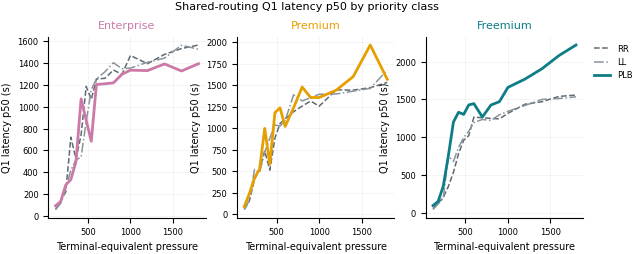

saved figures/selected/scheduler_campaign/shared_q1_latency_p95_by_class.pdf


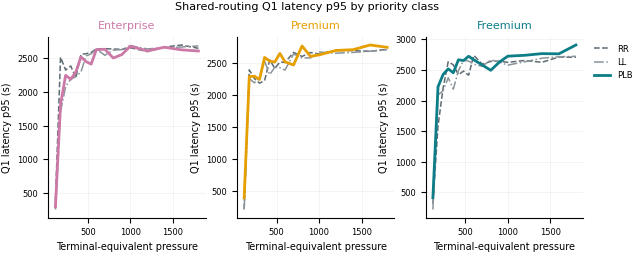

In [6]:
def plot_latency_by_class(metric_col, quantile, filename, schedulers=None):
    if schedulers is None:
        schedulers = [s for s in MAIN_SCHEDULERS if s in set(latency_main["scheduler"])]

    fig, axes = plt.subplots(1, 3, figsize=DOUBLE_COL, sharex=True, sharey=False)
    for ax, cls in zip(axes, CLASS_ORDER):
        data = latency_main[latency_main["class"] == cls]
        for sched in schedulers:
            sdata = data[data["scheduler"] == sched].sort_values("T")
            if sdata.empty:
                continue
            style = dict(SCHEDULER_STYLE.get(sched, {"linewidth": 1.0}))
            if sched == "plb_nclass":
                style["color"] = PALETTE[cls]
                style["linewidth"] = 2.0
            ax.plot(
                sdata["T"],
                sdata[metric_col],
                label=scheduler_label_for_class(sched, cls),
                **style,
            )
        ax.set_title(CLASS_LABELS[cls], color=PALETTE[cls])
        ax.set_xlabel("Terminal-equivalent pressure")
        ax.set_ylabel(f"Q1 latency {quantile} (s)")
    axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    fig.suptitle(f"Shared-routing Q1 latency {quantile} by priority class", y=1.03)
    save_figure(fig, filename)
    plt.show()

plot_latency_by_class("latency_p50_s", "p50", "shared_q1_latency_p50_by_class")
plot_latency_by_class("latency_p95_s", "p95", "shared_q1_latency_p95_by_class")


## Local Q1 concurrency by terminal-equivalent pressure

This overview compares local Q1 concurrency for the shared-routing baselines and PLB.


saved figures/selected/scheduler_campaign/shared_q1_concurrency_mean_by_class.pdf


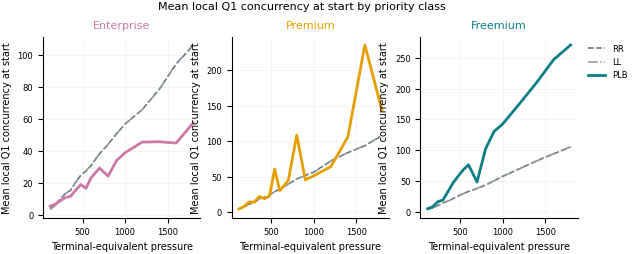

saved figures/selected/scheduler_campaign/shared_q1_concurrency_p95_by_class.pdf


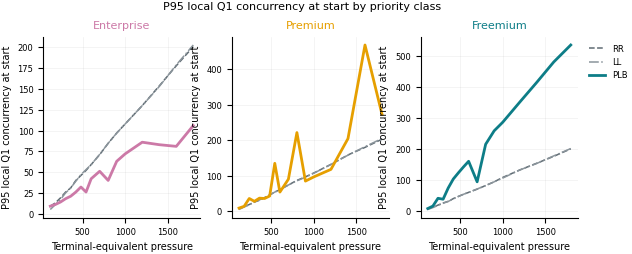

In [7]:
def plot_concurrency_by_class(metric_col, metric_label, filename, schedulers=None):
    if schedulers is None:
        schedulers = [s for s in MAIN_SCHEDULERS if s in set(concurrency_main["scheduler"])]

    fig, axes = plt.subplots(1, 3, figsize=DOUBLE_COL, sharex=True, sharey=False)
    for ax, cls in zip(axes, CLASS_ORDER):
        data = concurrency_main[concurrency_main["class"] == cls]
        for sched in schedulers:
            sdata = data[data["scheduler"] == sched].sort_values("T")
            if sdata.empty:
                continue
            style = dict(SCHEDULER_STYLE.get(sched, {"linewidth": 1.0}))
            if sched == "plb_nclass":
                style["color"] = PALETTE[cls]
                style["linewidth"] = 2.0
            ax.plot(
                sdata["T"],
                sdata[metric_col],
                label=scheduler_label_for_class(sched, cls),
                **style,
            )
        ax.set_title(CLASS_LABELS[cls], color=PALETTE[cls])
        ax.set_xlabel("Terminal-equivalent pressure")
        ax.set_ylabel(metric_label)
    axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    fig.suptitle(metric_label + " by priority class", y=1.03)
    save_figure(fig, filename)
    plt.show()

plot_concurrency_by_class(
    "q1_start_concurrency_mean",
    "Mean local Q1 concurrency at start",
    "shared_q1_concurrency_mean_by_class",
)
plot_concurrency_by_class(
    "q1_start_concurrency_p95",
    "P95 local Q1 concurrency at start",
    "shared_q1_concurrency_p95_by_class",
)


## Effective replicas

`effective_replicas` is computed from the time-weighted spread of each class over replicas. Static splits are kept as separate simulated runs.


saved figures/selected/scheduler_campaign/effective_replicas_by_class.pdf


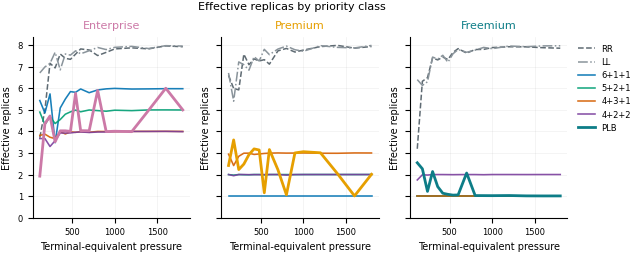

In [8]:
def plot_effective_replicas(schedulers=None):
    if schedulers is None:
        schedulers = [s for s in SCHEDULER_ORDER if s in set(concentration_main["scheduler"])]

    fig, axes = plt.subplots(1, 3, figsize=DOUBLE_COL, sharex=True, sharey=True)
    for ax, cls in zip(axes, CLASS_ORDER):
        data = concentration_main[concentration_main["class"] == cls]
        for sched in schedulers:
            sdata = data[data["scheduler"] == sched].sort_values("T")
            if sdata.empty:
                continue
            style = dict(SCHEDULER_STYLE.get(sched, {"linewidth": 1.0}))
            if sched == "plb_nclass":
                style["color"] = PALETTE[cls]
                style["linewidth"] = 2.0
            ax.plot(
                sdata["T"],
                sdata["effective_replicas"],
                label=scheduler_label_for_class(sched, cls),
                **style,
            )
        ax.set_title(CLASS_LABELS[cls], color=PALETTE[cls])
        ax.set_xlabel("Terminal-equivalent pressure")
        ax.set_ylabel("Effective replicas")
        ax.set_ylim(0, max(8.2, concentration_main["effective_replicas"].max() * 1.05))
    axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    fig.suptitle("Effective replicas by priority class", y=1.03)
    save_figure(fig, "effective_replicas_by_class")
    plt.show()

plot_effective_replicas()


## Relative Q1 latency of PLB versus baselines


saved figures/selected/scheduler_campaign/plb_q1_latency_ratio_to_baselines_p50.pdf


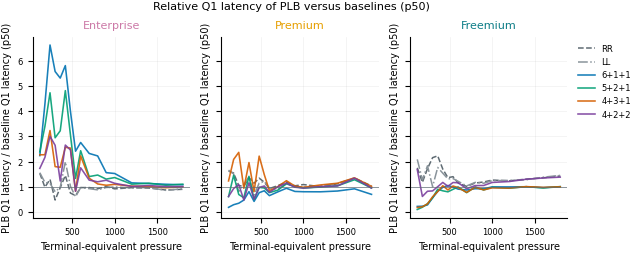

saved figures/selected/scheduler_campaign/plb_q1_latency_ratio_to_baselines_p95.pdf


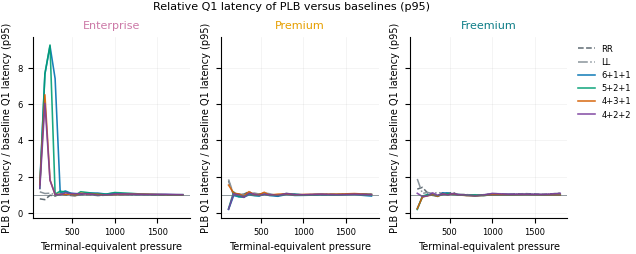

In [9]:
def plot_plb_ratio_vs_baselines(quantile, filename):
    data = baseline_cmp_main[
        (baseline_cmp_main["scheduler"] == "plb_nclass")
        & (baseline_cmp_main["class"].isin(CLASS_ORDER))
        & (baseline_cmp_main["quantile"] == quantile)
    ].copy()

    baselines = [
        s for s in ["round_robin", "least_loaded", "static_6_1_1", "static_5_2_1", "static_4_3_1", "static_4_2_2"]
        if s in set(data["baseline_scheduler"])
    ]

    fig, axes = plt.subplots(1, 3, figsize=DOUBLE_COL, sharex=True, sharey=True)
    for ax, cls in zip(axes, CLASS_ORDER):
        cdata = data[data["class"] == cls]
        for base in baselines:
            bdata = cdata[cdata["baseline_scheduler"] == base].sort_values("T")
            if bdata.empty:
                continue
            style = dict(SCHEDULER_STYLE.get(base, {"linewidth": 1.0}))
            ax.plot(
                bdata["T"],
                bdata["latency_ratio_to_baseline"],
                label=scheduler_label_for_class(base, cls),
                **style,
            )
        ax.axhline(1.0, color=PALETTE["dark_gray"], linewidth=0.7, alpha=0.7)
        ax.set_title(CLASS_LABELS[cls], color=PALETTE[cls])
        ax.set_xlabel("Terminal-equivalent pressure")
        ax.set_ylabel(f"PLB Q1 latency / baseline Q1 latency ({quantile})")
    axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    fig.suptitle(f"Relative Q1 latency of PLB versus baselines ({quantile})", y=1.03)
    save_figure(fig, filename)
    plt.show()

plot_plb_ratio_vs_baselines("p50", "plb_q1_latency_ratio_to_baselines_p50")
plot_plb_ratio_vs_baselines("p95", "plb_q1_latency_ratio_to_baselines_p95")


## Priority-ordering gap

The gap is zero when Enterprise is no slower than Premium and Premium is no slower than Freemium for the selected latency quantile.


saved figures/selected/scheduler_campaign/priority_violation_gap_p50.pdf


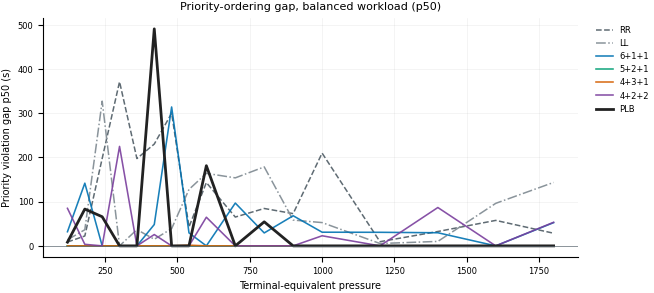

saved figures/selected/scheduler_campaign/priority_violation_gap_p95.pdf


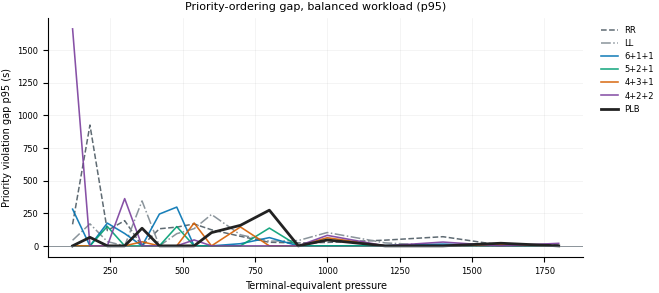

In [10]:
def plot_priority_violation_gap(quantile, filename, schedulers=None):
    metric_col = f"priority_violation_gap_{quantile}_s"
    if metric_col not in decision_main.columns:
        print("Missing column:", metric_col)
        return

    if schedulers is None:
        schedulers = [s for s in SCHEDULER_ORDER if s in set(decision_main["scheduler"])]

    data = decision_main[decision_main["scheduler"].isin(schedulers)].copy()
    if data.empty:
        print("No decision rows for selected schedulers")
        return

    fig, ax = plt.subplots(figsize=DOUBLE_COL_TALL)
    for sched in schedulers:
        sdata = data[data["scheduler"] == sched].sort_values("T")
        if sdata.empty:
            continue
        style = dict(SCHEDULER_STYLE.get(sched, {"linewidth": 1.0}))
        ax.plot(
            sdata["T"],
            sdata[metric_col],
            label=scheduler_label(sched),
            **style,
        )

    ax.axhline(0.0, color=PALETTE["dark_gray"], linewidth=0.7, alpha=0.7)
    ax.set_xlabel("Terminal-equivalent pressure")
    ax.set_ylabel(f"Priority violation gap {quantile} (s)")
    ax.set_title(f"Priority-ordering gap, {SELECTED_RATIO.replace('_', ' ')} workload ({quantile})")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    save_figure(fig, filename)
    plt.show()

plot_priority_violation_gap("p50", "priority_violation_gap_p50")
plot_priority_violation_gap("p95", "priority_violation_gap_p95")


## Dedicated static split comparison


Static split variability for p50 Q1 latency when class replica counts match:


,class,T,ratio,seed,dedicated_replicas,n_splits,min_latency_s,median_latency_s,max_latency_s,relative_spread
0,enterprise,120,balanced,42,4,2,42.016649,48.620701,55.224754,0.271656
3,enterprise,180,balanced,42,4,2,59.194271,60.661669,62.129066,0.048380
6,enterprise,240,balanced,42,4,2,88.084750,91.486581,94.888412,0.074368
9,enterprise,300,balanced,42,4,2,126.376828,156.293957,186.211086,0.382832
12,enterprise,360,balanced,42,4,2,281.631813,345.009406,408.386999,0.367396
15,enterprise,420,balanced,42,4,2,403.117138,410.063250,417.009363,0.033878
18,enterprise,480,balanced,42,4,2,345.214351,350.411343,355.608334,0.029662
21,enterprise,540,balanced,42,4,2,839.905762,840.091826,840.277890,0.000443
24,enterprise,600,balanced,42,4,2,540.615264,613.733595,686.851926,0.238274
27,enterprise,700,balanced,42,4,2,905.934329,933.543279,961.152229,0.059149


Static split variability for p95 Q1 latency when class replica counts match:


,class,T,ratio,seed,dedicated_replicas,n_splits,min_latency_s,median_latency_s,max_latency_s,relative_spread
0,enterprise,120,balanced,42,4,2,192.105647,206.537741,220.969835,0.139753
3,enterprise,180,balanced,42,4,2,277.586177,288.439805,299.293434,0.075257
6,enterprise,240,balanced,42,4,2,1233.771222,1243.526048,1253.280875,0.015689
9,enterprise,300,balanced,42,4,2,2164.836988,2173.092601,2181.348214,0.007598
12,enterprise,360,balanced,42,4,2,2254.087471,2295.997898,2337.908325,0.036507
15,enterprise,420,balanced,42,4,2,2276.122746,2384.098839,2492.074932,0.090580
18,enterprise,480,balanced,42,4,2,2328.251722,2348.741361,2369.230999,0.017447
21,enterprise,540,balanced,42,4,2,2273.578479,2397.350290,2521.122101,0.103257
24,enterprise,600,balanced,42,4,2,2434.829247,2477.664958,2520.500668,0.034577
27,enterprise,700,balanced,42,4,2,2520.301360,2537.255387,2554.209414,0.013364


saved figures/selected/scheduler_campaign/dedicated_static_q1_latency_p50_by_class.pdf


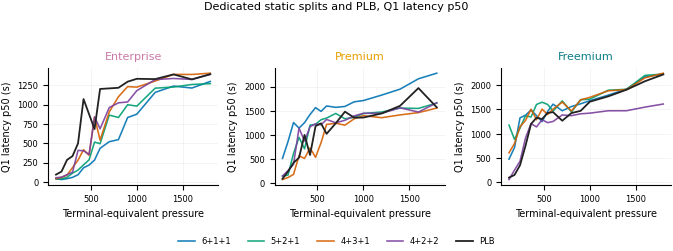

saved figures/selected/scheduler_campaign/dedicated_static_q1_latency_p95_by_class.pdf


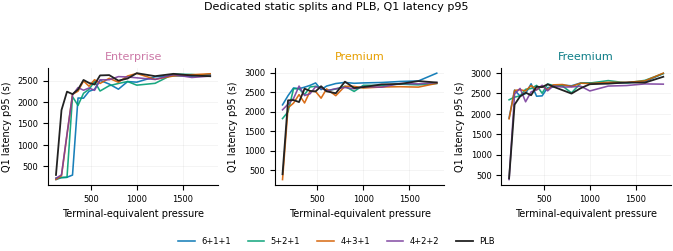

saved figures/selected/scheduler_campaign/dedicated_static_q1_concurrency_mean_by_class.pdf


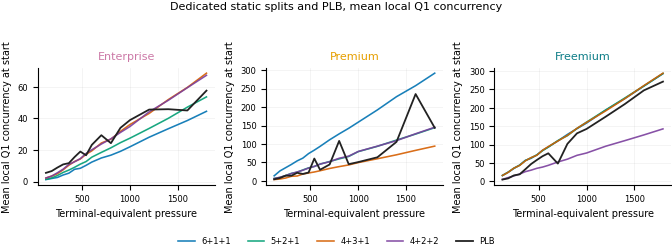

saved figures/selected/scheduler_campaign/dedicated_static_q1_concurrency_p95_by_class.pdf


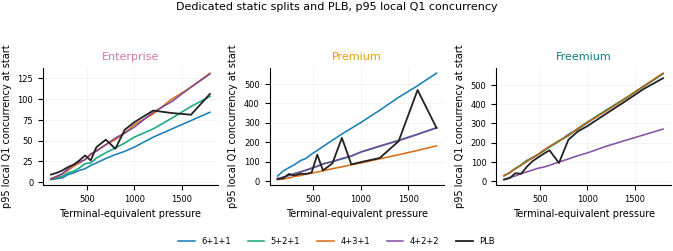

In [11]:
def static_split_variability(quantile):
    metric_col = f"latency_{quantile}_s"
    rows = latency_main[
        (latency_main["scheduler"].isin(STATIC_SCHEDULERS))
        & (latency_main["class"].isin(CLASS_ORDER))
    ].copy()

    rows["dedicated_replicas"] = rows.apply(
        lambda row: static_replicas_for_class(row["scheduler"], row["class"]),
        axis=1,
    )

    grouped = (
        rows.groupby(["class", "T", "ratio", "seed", "dedicated_replicas"], as_index=False)
        .agg(
            n_splits=("scheduler", "nunique"),
            min_latency_s=(metric_col, "min"),
            median_latency_s=(metric_col, "median"),
            max_latency_s=(metric_col, "max"),
        )
    )
    grouped = grouped[grouped["n_splits"] > 1].copy()
    grouped["relative_spread"] = (
        grouped["max_latency_s"] - grouped["min_latency_s"]
    ) / grouped["median_latency_s"]
    return grouped.sort_values(["class", "dedicated_replicas", "T"])

print("Static split variability for p50 Q1 latency when class replica counts match:")
display(static_split_variability("p50"))
print("Static split variability for p95 Q1 latency when class replica counts match:")
display(static_split_variability("p95"))

def plot_dedicated_static_by_class(
    table,
    metric_col,
    ylabel,
    figure_title,
    filename,
    T_col="T",
):
    schedulers = [s for s in STATIC_SCHEDULERS + ["plb_nclass"] if s in set(table["scheduler"])]
    fig, axes = plt.subplots(1, 3, figsize=DOUBLE_COL, sharex=True, sharey=False)

    for ax, cls in zip(axes, CLASS_ORDER):
        data = table[table["class"] == cls]
        for sched in schedulers:
            sdata = data[data["scheduler"] == sched].sort_values(T_col)
            if sdata.empty:
                continue

            style = dict(SCHEDULER_STYLE.get(sched, {"linewidth": 1.0}))
            if sched == "plb_nclass":
                style.update({
                    "color": PALETTE["black"],
                    "linewidth": 1.3,
                    "linestyle": "-",
                    "alpha": 1.0,
                })

            ax.plot(
                sdata[T_col],
                sdata[metric_col],
                label=scheduler_label(sched),
                **style,
            )

        ax.set_title(CLASS_LABELS[cls], color=PALETTE[cls])
        ax.set_xlabel("Terminal-equivalent pressure")
        ax.set_ylabel(ylabel)

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.03))
    fig.suptitle(figure_title, y=1.04)
    fig.tight_layout(rect=(0, 0.07, 1, 0.96))
    save_figure(fig, filename)
    plt.show()

plot_dedicated_static_by_class(
    latency_main,
    "latency_p50_s",
    "Q1 latency p50 (s)",
    "Dedicated static splits and PLB, Q1 latency p50",
    "dedicated_static_q1_latency_p50_by_class",
)
plot_dedicated_static_by_class(
    latency_main,
    "latency_p95_s",
    "Q1 latency p95 (s)",
    "Dedicated static splits and PLB, Q1 latency p95",
    "dedicated_static_q1_latency_p95_by_class",
)
plot_dedicated_static_by_class(
    concurrency_main,
    "q1_start_concurrency_mean",
    "Mean local Q1 concurrency at start",
    "Dedicated static splits and PLB, mean local Q1 concurrency",
    "dedicated_static_q1_concurrency_mean_by_class",
)
plot_dedicated_static_by_class(
    concurrency_main,
    "q1_start_concurrency_p95",
    "p95 local Q1 concurrency at start",
    "Dedicated static splits and PLB, p95 local Q1 concurrency",
    "dedicated_static_q1_concurrency_p95_by_class",
)


## Ratio sensitivity

This section keeps all terminal-equivalent pressure levels within the main range and compares workload mixes without averaging across ratios. The detailed sections above use the selected balanced ratio; the figures below use all available ratios.


saved figures/selected/scheduler_campaign/ratio_sensitivity_plb_q1_latency_p50.pdf


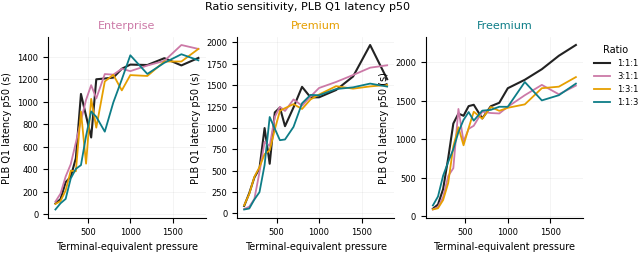

saved figures/selected/scheduler_campaign/ratio_sensitivity_plb_q1_latency_p95.pdf


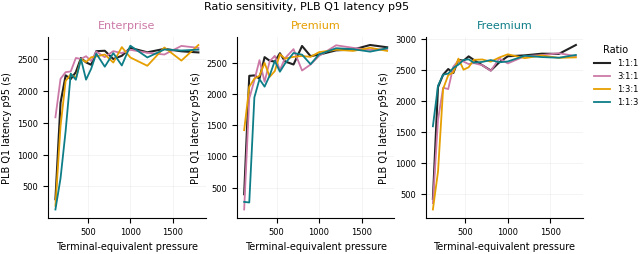

saved figures/selected/scheduler_campaign/ratio_sensitivity_plb_rr_q1_latency_p50.pdf


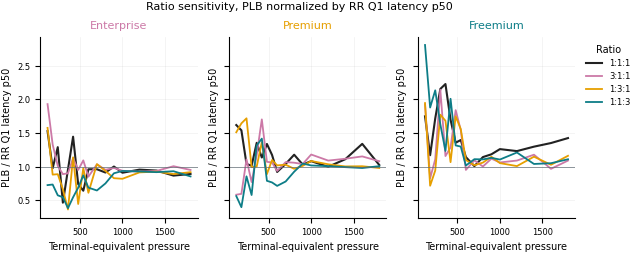

saved figures/selected/scheduler_campaign/ratio_sensitivity_plb_rr_q1_latency_p95.pdf


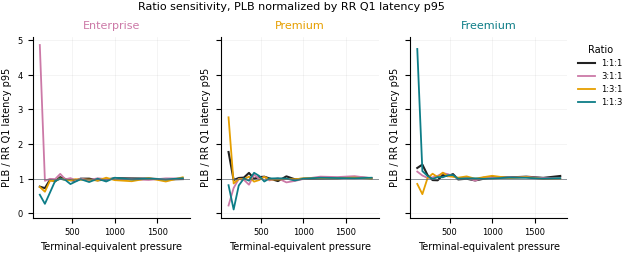

saved figures/selected/scheduler_campaign/ratio_sensitivity_plb_priority_gap_p95.pdf


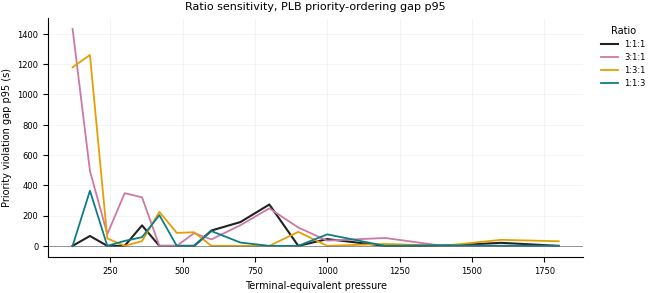

saved figures/selected/scheduler_campaign/ratio_sensitivity_freemium_cost_p50.pdf


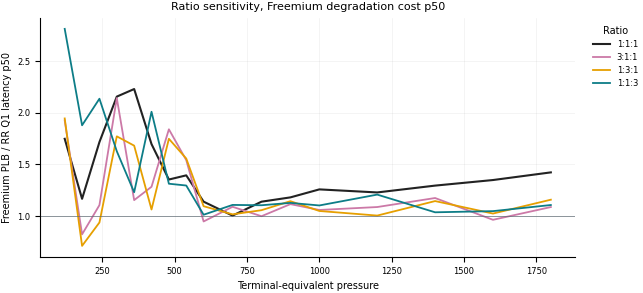

saved figures/selected/scheduler_campaign/ratio_sensitivity_freemium_cost_p95.pdf


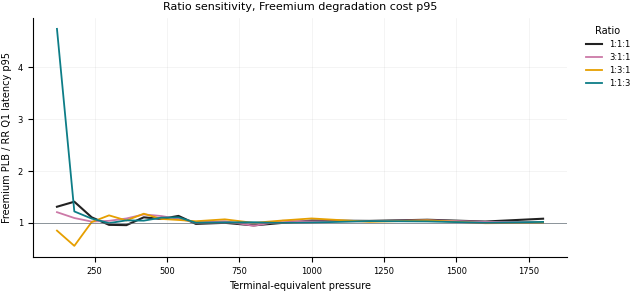

SENSITIVITY_CAMPAIGN_DIR = /home/spirals/phd/experiments/plb_batsim/outputs_query/scheduler_campaign_ratios_T1800
latency ratios = ['balanced', 'enterprise_heavy', 'freemium_heavy', 'premium_heavy']
baseline ratios = ['balanced', 'enterprise_heavy', 'freemium_heavy', 'premium_heavy']
decision ratios = ['balanced', 'enterprise_heavy', 'freemium_heavy', 'premium_heavy']


In [12]:
def plot_plb_latency_by_ratio(metric_col, quantile, filename):
    data = latency_sensitivity[
        (latency_sensitivity["scheduler"] == "plb_nclass")
        & (latency_sensitivity["class"].isin(CLASS_ORDER))
    ].copy()

    ratios = available_ratio_order(data)
    if not ratios:
        print("No ratio column found")
        return

    fig, axes = plt.subplots(1, 3, figsize=DOUBLE_COL, sharex=True, sharey=False)
    for ax, cls in zip(axes, CLASS_ORDER):
        cdata = data[data["class"] == cls]
        for ratio in ratios:
            rdata = cdata[cdata["ratio"] == ratio].sort_values("T")
            if rdata.empty:
                continue
            style = dict(RATIO_STYLE.get(ratio, {"linewidth": 1.0}))
            ax.plot(
                rdata["T"],
                rdata[metric_col],
                label=ratio_label(ratio),
                **style,
            )
        ax.set_title(CLASS_LABELS[cls], color=PALETTE[cls])
        ax.set_xlabel("Terminal-equivalent pressure")
        ax.set_ylabel(f"PLB Q1 latency {quantile} (s)")

    axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, title="Ratio")
    fig.suptitle(f"Ratio sensitivity, PLB Q1 latency {quantile}", y=1.03)
    save_figure(fig, filename)
    plt.show()


def plot_plb_rr_ratio_by_ratio(quantile, filename):
    data = baseline_cmp_sensitivity[
        (baseline_cmp_sensitivity["scheduler"] == "plb_nclass")
        & (baseline_cmp_sensitivity["baseline_scheduler"] == "round_robin")
        & (baseline_cmp_sensitivity["class"].isin(CLASS_ORDER))
        & (baseline_cmp_sensitivity["quantile"] == quantile)
    ].copy()

    ratios = available_ratio_order(data)
    if not ratios:
        print("No ratio column found")
        return

    fig, axes = plt.subplots(1, 3, figsize=DOUBLE_COL, sharex=True, sharey=True)
    for ax, cls in zip(axes, CLASS_ORDER):
        cdata = data[data["class"] == cls]
        for ratio in ratios:
            rdata = cdata[cdata["ratio"] == ratio].sort_values("T")
            if rdata.empty:
                continue
            style = dict(RATIO_STYLE.get(ratio, {"linewidth": 1.0}))
            ax.plot(
                rdata["T"],
                rdata["latency_ratio_to_baseline"],
                label=ratio_label(ratio),
                **style,
            )
        ax.axhline(1.0, color=PALETTE["dark_gray"], linewidth=0.7, alpha=0.7)
        ax.set_title(CLASS_LABELS[cls], color=PALETTE[cls])
        ax.set_xlabel("Terminal-equivalent pressure")
        ax.set_ylabel(f"PLB / RR Q1 latency {quantile}")

    axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, title="Ratio")
    fig.suptitle(f"Ratio sensitivity, PLB normalized by RR Q1 latency {quantile}", y=1.03)
    save_figure(fig, filename)
    plt.show()


def plot_plb_priority_gap_by_ratio(quantile, filename):
    metric_col = f"priority_violation_gap_{quantile}_s"
    if metric_col not in decision_sensitivity.columns:
        print("Missing column:", metric_col)
        return

    data = decision_sensitivity[decision_sensitivity["scheduler"] == "plb_nclass"].copy()
    ratios = available_ratio_order(data)
    if not ratios:
        print("No ratio column found")
        return

    fig, ax = plt.subplots(figsize=DOUBLE_COL_TALL)
    for ratio in ratios:
        rdata = data[data["ratio"] == ratio].sort_values("T")
        if rdata.empty:
            continue
        style = dict(RATIO_STYLE.get(ratio, {"linewidth": 1.0}))
        ax.plot(
            rdata["T"],
            rdata[metric_col],
            label=ratio_label(ratio),
            **style,
        )

    ax.axhline(0.0, color=PALETTE["dark_gray"], linewidth=0.7, alpha=0.7)
    ax.set_xlabel("Terminal-equivalent pressure")
    ax.set_ylabel(f"Priority violation gap {quantile} (s)")
    ax.set_title(f"Ratio sensitivity, PLB priority-ordering gap {quantile}")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, title="Ratio")
    save_figure(fig, filename)
    plt.show()


def plot_freemium_cost_by_ratio(quantile, filename):
    metric_col = f"freemium_cost_vs_round_robin_{quantile}"
    if metric_col not in decision_sensitivity.columns:
        print("Missing column:", metric_col)
        return

    data = decision_sensitivity[decision_sensitivity["scheduler"] == "plb_nclass"].copy()
    ratios = available_ratio_order(data)
    if not ratios:
        print("No ratio column found")
        return

    fig, ax = plt.subplots(figsize=DOUBLE_COL_TALL)
    for ratio in ratios:
        rdata = data[data["ratio"] == ratio].sort_values("T")
        if rdata.empty:
            continue
        style = dict(RATIO_STYLE.get(ratio, {"linewidth": 1.0}))
        ax.plot(
            rdata["T"],
            rdata[metric_col],
            label=ratio_label(ratio),
            **style,
        )

    ax.axhline(1.0, color=PALETTE["dark_gray"], linewidth=0.7, alpha=0.7)
    ax.set_xlabel("Terminal-equivalent pressure")
    ax.set_ylabel(f"Freemium PLB / RR Q1 latency {quantile}")
    ax.set_title(f"Ratio sensitivity, Freemium degradation cost {quantile}")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, title="Ratio")
    save_figure(fig, filename)
    plt.show()

plot_plb_latency_by_ratio("latency_p50_s", "p50", "ratio_sensitivity_plb_q1_latency_p50")
plot_plb_latency_by_ratio("latency_p95_s", "p95", "ratio_sensitivity_plb_q1_latency_p95")

plot_plb_rr_ratio_by_ratio("p50", "ratio_sensitivity_plb_rr_q1_latency_p50")
plot_plb_rr_ratio_by_ratio("p95", "ratio_sensitivity_plb_rr_q1_latency_p95")

plot_plb_priority_gap_by_ratio("p95", "ratio_sensitivity_plb_priority_gap_p95")

plot_freemium_cost_by_ratio("p50", "ratio_sensitivity_freemium_cost_p50")
plot_freemium_cost_by_ratio("p95", "ratio_sensitivity_freemium_cost_p95")

print("SENSITIVITY_CAMPAIGN_DIR =", SENSITIVITY_CAMPAIGN_DIR)
print("latency ratios =", sorted(latency_sensitivity["ratio"].dropna().unique()))
print("baseline ratios =", sorted(baseline_cmp_sensitivity["ratio"].dropna().unique()))
print("decision ratios =", sorted(decision_sensitivity["ratio"].dropna().unique()))

## Replica composition at a selected pressure

The stacked bars show the time-weighted class composition of each replica. All baselines and PLB are shown for the selected pressure.


saved figures/selected/scheduler_campaign/replica_composition_grid_T600.pdf


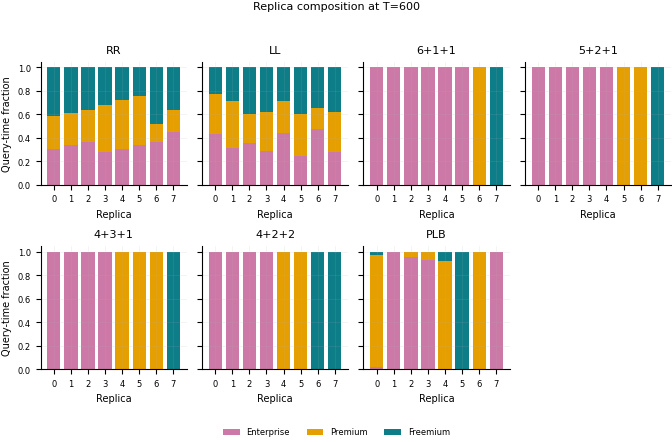

In [13]:
def plot_replica_composition_grid(T=600, ratio="balanced", seed=42, schedulers=None):
    if schedulers is None:
        schedulers = [s for s in SCHEDULER_ORDER if s in set(composition_main["scheduler"])]

    ncols = 4
    nrows = int(np.ceil(len(schedulers) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=GRID_FIG, sharex=False, sharey=True)
    axes = np.array(axes).reshape(-1)

    for ax, scheduler in zip(axes, schedulers):
        data = composition_main[
            (composition_main["scheduler"] == scheduler)
            & (composition_main["T"] == T)
            & (composition_main["ratio"] == ratio)
            & (composition_main["seed"] == seed)
        ].sort_values("replica")

        if data.empty:
            ax.set_axis_off()
            continue

        bottom = np.zeros(len(data))
        x = data["replica"].astype(int).to_numpy()

        for cls in CLASS_ORDER:
            col = f"{cls}_query_time_fraction"
            values = data[col].to_numpy()
            ax.bar(x, values, bottom=bottom, color=PALETTE[cls], width=0.78)
            bottom += values

        ax.set_ylim(0, 1.05)
        ax.set_title(scheduler_label(scheduler))
        ax.set_xlabel("Replica")
        ax.set_xticks(x)
        ax.tick_params(axis="x", labelrotation=0)
        if ax is axes[0] or ax.get_subplotspec().is_first_col():
            ax.set_ylabel("Query-time fraction")
        else:
            ax.set_ylabel("")

    for ax in axes[len(schedulers):]:
        ax.set_axis_off()

    handles = [Patch(facecolor=PALETTE[cls], label=CLASS_LABELS[cls]) for cls in CLASS_ORDER]
    fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(f"Replica composition at T={T}", y=1.01)
    fig.tight_layout(rect=(0, 0.05, 1, 0.98))
    save_figure(fig, f"replica_composition_grid_T{T}")
    plt.show()

plot_replica_composition_grid(T=600)


## Decision table preview

Compact view of priority-ordering and Freemium degradation indicators.

In [14]:
preferred_columns = [
    "scheduler", "K", "T", "ratio", "seed",
    "priority_violation_p50", "priority_violation_p95",
    "priority_violation_gap_p50_s", "priority_violation_gap_p95_s",
    "freemium_cost_vs_round_robin_p50", "freemium_cost_vs_round_robin_p95",
    "freemium_cost_vs_least_loaded_p50", "freemium_cost_vs_least_loaded_p95",
    "bounded_degradation_ok_p50", "bounded_degradation_ok_p95",
]
cols = [c for c in preferred_columns if c in decision.columns]
if cols:
    display(decision_main[cols].sort_values(["T", "scheduler"]).reset_index(drop=True))
else:
    display(decision_main.head())


,scheduler,K,T,ratio,seed,priority_violation_p50,priority_violation_p95,priority_violation_gap_p50_s,priority_violation_gap_p95_s,freemium_cost_vs_round_robin_p50,freemium_cost_vs_round_robin_p95,freemium_cost_vs_least_loaded_p50,freemium_cost_vs_least_loaded_p95,bounded_degradation_ok_p50,bounded_degradation_ok_p95
0,global_target_repair_neutral,8,120,balanced,42,False,False,0.000000,0.000000,3.715777,6.896536,4.434565,9.868415,False,False
1,global_target_repair_neutral_init_4_2_2,8,120,balanced,42,True,True,84.418432,38.054028,2.690489,6.706754,3.210943,9.596852,False,False
2,global_target_repair_target_only,8,120,balanced,42,True,True,84.418432,38.054028,2.690489,6.706754,3.210943,9.596852,False,False
3,global_target_repair_target_only_init_4_2_2,8,120,balanced,42,True,True,84.418432,38.054028,2.690489,6.706754,3.210943,9.596852,False,False
4,least_loaded,8,120,balanced,42,True,True,13.704422,42.763653,0.837913,0.698849,1.000000,1.000000,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,round_robin,8,1800,balanced,42,True,True,28.584926,8.401985,1.000000,1.000000,1.015867,0.994276,True,True
183,static_4_2_2,8,1800,balanced,42,True,True,53.292423,19.481624,1.034202,1.006949,1.050612,1.001186,True,True
184,static_4_3_1,8,1800,balanced,42,False,False,0.000000,0.000000,1.441108,1.106441,1.463973,1.100108,True,True
185,static_5_2_1,8,1800,balanced,42,False,False,0.000000,0.000000,1.429597,1.103015,1.452280,1.096702,True,True


## Inspection checklist

- Q1 latency p50 and p95 for each priority class.
- Local Q1 concurrency at query start for each priority class.
- Effective replicas and top-replica concentration.
- PLB-to-baseline Q1 latency ratios.
- Dedicated static splits as simulated, not merged by class replica count.
- Priority-ordering gap for p50 and p95.
- Ratio sensitivity for PLB latency p50 and p95.
- Ratio sensitivity for PLB/RR normalized latency p50 and p95.
- Ratio sensitivity for Freemium degradation cost.
- Calibration-support table by ratio and terminal pressure.
- Replica composition across all baselines at the selected pressure.


## Candidate algorithm comparison: N-class PLB and target-repair variants

This section compares the direct N-class PLB extension with the target-repair controllers on the same balanced campaign.

- `plb_nclass`: direct N-class extension of PLB.
- `global_target_repair_neutral`: target-repair v1 with the original initialization `E1 P3 F3 M1`.
- `global_target_repair_target_only`: target-repair v2 with the original initialization `E1 P3 F3 M1`.
- `global_target_repair_neutral_init_4_2_2`: target-repair v1 initialized as `E4 P2 F2 M0`.
- `global_target_repair_target_only_init_4_2_2`: target-repair v2 initialized as `E4 P2 F2 M0`.

The two `init_4_2_2` variants test whether the first target-repair results were mostly affected by the initial allocation. They do not change the target computation. They only start with more Enterprise capacity and no passive Mixed role.

For a candidate allocation $k$ and active demand $D_c$, the class pressure is:

$$
    p_c(k) = rac{D_c}{k_c}
$$

The desired pressure order follows the priority order:

$$
    p_E \leq p_P \leq p_F
$$

The controller therefore minimizes the priority-inversion cost first:

$$
    \mathrm{Inv}(k) = \sum_i \maxigl(0, p_{c_i}(k) - p_{c_{i+1}}(k)igr)^2
$$

where the active classes are ordered as Enterprise, Premium, Freemium. A zero value means that the pressure order respects priority: Enterprise is not more pressured than Premium, and Premium is not more pressured than Freemium.

Among allocations with equal inversion cost, the controller minimizes the pressure-balance cost:

$$
    \mathrm{Bal}(k) = \sum_{c \in active} p_c(k)^2
$$

Then it minimizes the distance from the current allocation. The v2 rule changes only the neutral repair step: when there is no inversion, it accepts only moves that bring the current allocation closer to the computed target $k^*$.


In [15]:
ALGO_SCHEDULERS = [
    "plb_nclass",
    "global_target_repair_neutral",
    "global_target_repair_target_only",
    "global_target_repair_neutral_init_4_2_2",
    "global_target_repair_target_only_init_4_2_2",
]

ALGO_LABELS = {
    "plb_nclass": "N-class PLB",
    "global_target_repair_neutral": "Target-repair v1",
    "global_target_repair_target_only": "Target-repair v2",
    "global_target_repair_neutral_init_4_2_2": "Target-repair v1, init 4-2-2",
    "global_target_repair_target_only_init_4_2_2": "Target-repair v2, init 4-2-2",
}

ALGO_STYLE = {
    "plb_nclass": {
        "color": PALETTE["black"],
        "linewidth": 1.7,
        "linestyle": "-",
        "marker": "o",
        "markersize": 2.7,
        "markerfacecolor": "none",
    },
    "global_target_repair_neutral": {
        "color": "#0072B2",
        "linewidth": 1.45,
        "linestyle": "-",
        "marker": "s",
        "markersize": 2.6,
        "markerfacecolor": "none",
    },
    "global_target_repair_target_only": {
        "color": "#D55E00",
        "linewidth": 1.65,
        "linestyle": "-",
        "marker": "D",
        "markersize": 2.5,
        "markerfacecolor": "none",
    },
    "global_target_repair_neutral_init_4_2_2": {
        "color": "#7A3E9D",
        "linewidth": 1.45,
        "linestyle": "-",
        "marker": "^",
        "markersize": 2.7,
        "markerfacecolor": "none",
    },
    "global_target_repair_target_only_init_4_2_2": {
        "color": "#009E73",
        "linewidth": 1.85,
        "linestyle": "-",
        "marker": "v",
        "markersize": 2.7,
        "markerfacecolor": "none",
    },
}
configure_marker_styles(ALGO_STYLE)

ALGO_RATIO = SELECTED_RATIO
ALGO_AVAILABLE = [s for s in ALGO_SCHEDULERS if s in set(latency_main["scheduler"])]
ALGO_TARGET_REPAIR = [s for s in ALGO_AVAILABLE if s.startswith("global_target_repair")]

print("Candidate comparison schedulers:", ALGO_AVAILABLE)
print("Candidate comparison ratio:", ALGO_RATIO)

missing_algo = [s for s in ALGO_SCHEDULERS if s not in ALGO_AVAILABLE]
if missing_algo:
    print("Missing in aggregated metrics:", missing_algo)


Candidate comparison schedulers: ['plb_nclass', 'global_target_repair_neutral', 'global_target_repair_target_only', 'global_target_repair_neutral_init_4_2_2', 'global_target_repair_target_only_init_4_2_2']
Candidate comparison ratio: balanced


saved figures/selected/scheduler_campaign/algo_compare_candidates_latency_p50.pdf


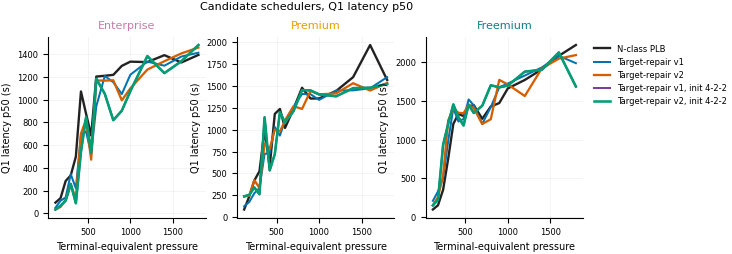

saved figures/selected/scheduler_campaign/algo_compare_candidates_latency_p95.pdf


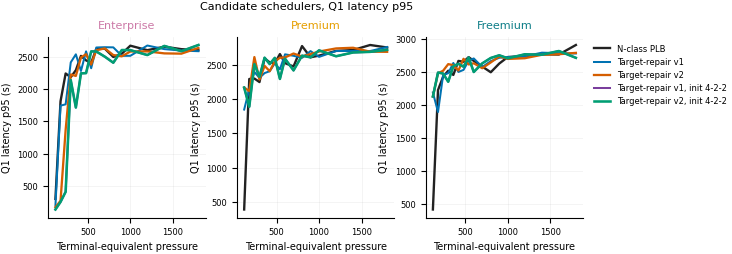

In [16]:
def plot_algo_latency_comparison(metric_col, quantile, filename):
    data = latency_main[
        (latency_main["scheduler"].isin(ALGO_AVAILABLE))
        & (latency_main["class"].isin(CLASS_ORDER))
    ].copy()

    if data.empty:
        print("No latency rows for candidate comparison")
        return

    fig, axes = plt.subplots(1, 3, figsize=DOUBLE_COL, sharex=True, sharey=False)
    for ax, cls in zip(axes, CLASS_ORDER):
        cdata = data[data["class"] == cls]
        for sched in ALGO_AVAILABLE:
            sdata = cdata[cdata["scheduler"] == sched].sort_values("T")
            if sdata.empty:
                continue
            ax.plot(
                sdata["T"],
                sdata[metric_col],
                label=ALGO_LABELS.get(sched, scheduler_label(sched)),
                **dict(ALGO_STYLE.get(sched, {"linewidth": 1.0})),
            )
        ax.set_title(CLASS_LABELS[cls], color=PALETTE[cls])
        ax.set_xlabel("Terminal-equivalent pressure")
        ax.set_ylabel(f"Q1 latency {quantile} (s)")

    axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    fig.suptitle(f"Candidate schedulers, Q1 latency {quantile}", y=1.03)
    save_figure(fig, filename)
    plt.show()

plot_algo_latency_comparison("latency_p50_s", "p50", "algo_compare_candidates_latency_p50")
plot_algo_latency_comparison("latency_p95_s", "p95", "algo_compare_candidates_latency_p95")


saved figures/selected/scheduler_campaign/algo_compare_candidates_concurrency_mean.pdf


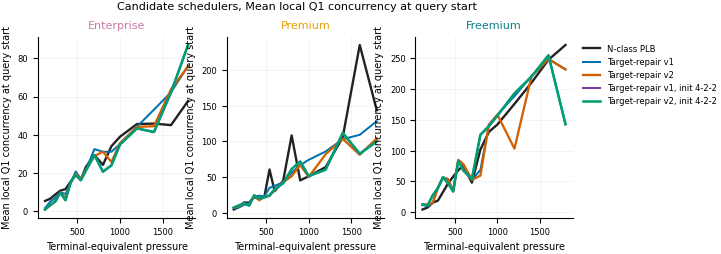

saved figures/selected/scheduler_campaign/algo_compare_candidates_concurrency_p95.pdf


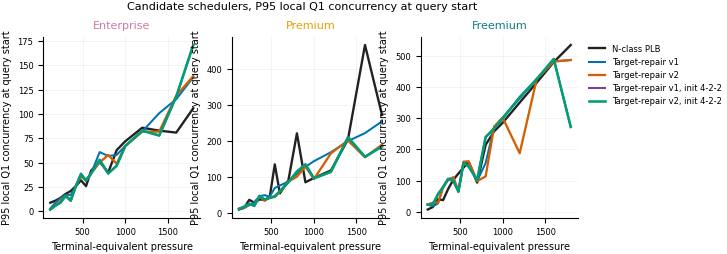

In [17]:
def plot_algo_concurrency_comparison(metric_col, metric_label, filename):
    data = concurrency_main[
        (concurrency_main["scheduler"].isin(ALGO_AVAILABLE))
        & (concurrency_main["class"].isin(CLASS_ORDER))
    ].copy()

    if data.empty:
        print("No concurrency rows for candidate comparison")
        return

    fig, axes = plt.subplots(1, 3, figsize=DOUBLE_COL, sharex=True, sharey=False)
    for ax, cls in zip(axes, CLASS_ORDER):
        cdata = data[data["class"] == cls]
        for sched in ALGO_AVAILABLE:
            sdata = cdata[cdata["scheduler"] == sched].sort_values("T")
            if sdata.empty:
                continue
            ax.plot(
                sdata["T"],
                sdata[metric_col],
                label=ALGO_LABELS.get(sched, scheduler_label(sched)),
                **dict(ALGO_STYLE.get(sched, {"linewidth": 1.0})),
            )
        ax.set_title(CLASS_LABELS[cls], color=PALETTE[cls])
        ax.set_xlabel("Terminal-equivalent pressure")
        ax.set_ylabel(metric_label)

    axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    fig.suptitle(f"Candidate schedulers, {metric_label}", y=1.03)
    save_figure(fig, filename)
    plt.show()

plot_algo_concurrency_comparison(
    "q1_start_concurrency_mean",
    "Mean local Q1 concurrency at query start",
    "algo_compare_candidates_concurrency_mean",
)
plot_algo_concurrency_comparison(
    "q1_start_concurrency_p95",
    "P95 local Q1 concurrency at query start",
    "algo_compare_candidates_concurrency_p95",
)


saved figures/selected/scheduler_campaign/algo_compare_candidates_priority_gap_p50.pdf


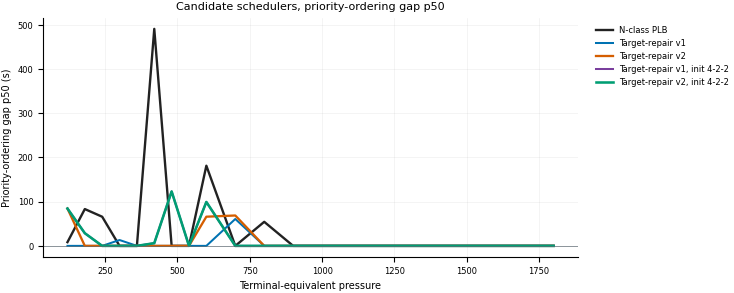

saved figures/selected/scheduler_campaign/algo_compare_candidates_priority_gap_p95.pdf


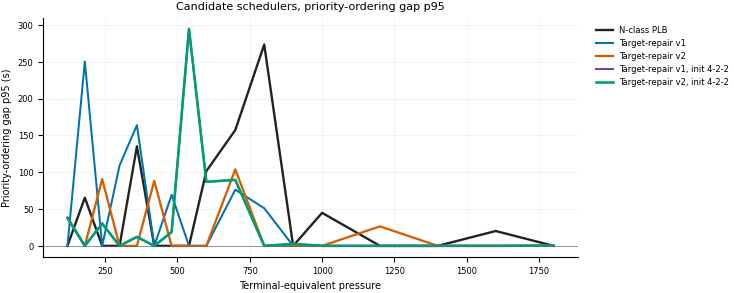

saved figures/selected/scheduler_campaign/algo_compare_candidates_freemium_cost_p50.pdf


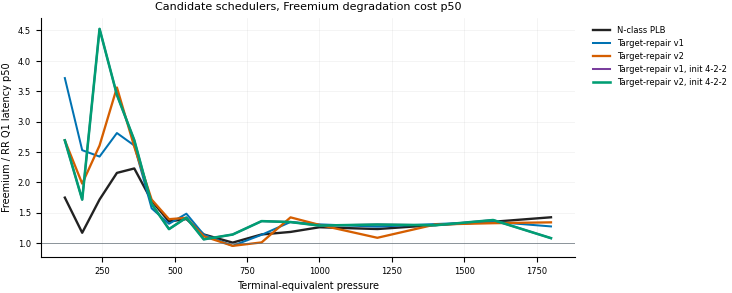

saved figures/selected/scheduler_campaign/algo_compare_candidates_freemium_cost_p95.pdf


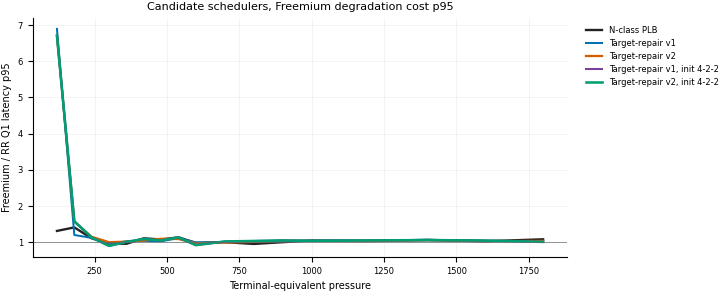

In [18]:
def plot_algo_priority_gap(quantile, filename):
    metric_col = f"priority_violation_gap_{quantile}_s"
    if metric_col not in decision_main.columns:
        print("Missing column:", metric_col)
        return

    data = decision_main[decision_main["scheduler"].isin(ALGO_AVAILABLE)].copy()
    if data.empty:
        print("No decision rows for candidate comparison")
        return

    fig, ax = plt.subplots(figsize=DOUBLE_COL_TALL)
    for sched in ALGO_AVAILABLE:
        sdata = data[data["scheduler"] == sched].sort_values("T")
        if sdata.empty:
            continue
        ax.plot(
            sdata["T"],
            sdata[metric_col],
            label=ALGO_LABELS.get(sched, scheduler_label(sched)),
            **dict(ALGO_STYLE.get(sched, {"linewidth": 1.0})),
        )

    ax.axhline(0.0, color=PALETTE["dark_gray"], linewidth=0.7, alpha=0.7)
    ax.set_xlabel("Terminal-equivalent pressure")
    ax.set_ylabel(f"Priority-ordering gap {quantile} (s)")
    ax.set_title(f"Candidate schedulers, priority-ordering gap {quantile}")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    save_figure(fig, filename)
    plt.show()


def plot_algo_freemium_cost(quantile, filename):
    metric_col = f"freemium_cost_vs_round_robin_{quantile}"
    if metric_col not in decision_main.columns:
        print("Missing column:", metric_col)
        return

    data = decision_main[decision_main["scheduler"].isin(ALGO_AVAILABLE)].copy()
    if data.empty:
        print("No decision rows for candidate comparison")
        return

    fig, ax = plt.subplots(figsize=DOUBLE_COL_TALL)
    for sched in ALGO_AVAILABLE:
        sdata = data[data["scheduler"] == sched].sort_values("T")
        if sdata.empty:
            continue
        ax.plot(
            sdata["T"],
            sdata[metric_col],
            label=ALGO_LABELS.get(sched, scheduler_label(sched)),
            **dict(ALGO_STYLE.get(sched, {"linewidth": 1.0})),
        )

    ax.axhline(1.0, color=PALETTE["dark_gray"], linewidth=0.7, alpha=0.7)
    ax.set_xlabel("Terminal-equivalent pressure")
    ax.set_ylabel(f"Freemium / RR Q1 latency {quantile}")
    ax.set_title(f"Candidate schedulers, Freemium degradation cost {quantile}")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    save_figure(fig, filename)
    plt.show()

plot_algo_priority_gap("p50", "algo_compare_candidates_priority_gap_p50")
plot_algo_priority_gap("p95", "algo_compare_candidates_priority_gap_p95")
plot_algo_freemium_cost("p50", "algo_compare_candidates_freemium_cost_p50")
plot_algo_freemium_cost("p95", "algo_compare_candidates_freemium_cost_p95")


saved figures/selected/scheduler_campaign/algo_compare_candidates_effective_replicas.pdf


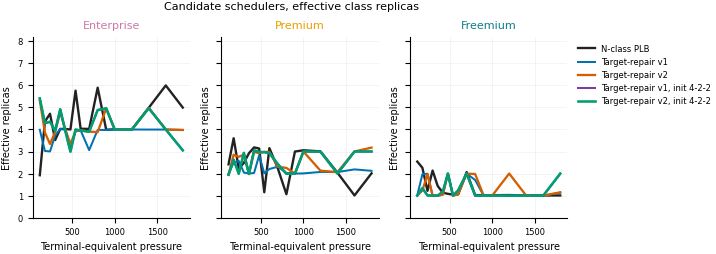

saved figures/selected/scheduler_campaign/algo_compare_candidates_top_replica_fraction.pdf


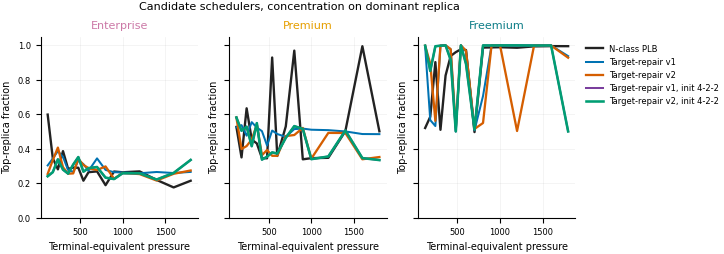

In [19]:
def plot_algo_effective_replicas(filename):
    data = concentration_main[
        (concentration_main["scheduler"].isin(ALGO_AVAILABLE))
        & (concentration_main["class"].isin(CLASS_ORDER))
    ].copy()

    if data.empty:
        print("No concentration rows for candidate comparison")
        return

    fig, axes = plt.subplots(1, 3, figsize=DOUBLE_COL, sharex=True, sharey=True)
    for ax, cls in zip(axes, CLASS_ORDER):
        cdata = data[data["class"] == cls]
        for sched in ALGO_AVAILABLE:
            sdata = cdata[cdata["scheduler"] == sched].sort_values("T")
            if sdata.empty:
                continue
            ax.plot(
                sdata["T"],
                sdata["effective_replicas"],
                label=ALGO_LABELS.get(sched, scheduler_label(sched)),
                **dict(ALGO_STYLE.get(sched, {"linewidth": 1.0})),
            )
        ax.set_title(CLASS_LABELS[cls], color=PALETTE[cls])
        ax.set_xlabel("Terminal-equivalent pressure")
        ax.set_ylabel("Effective replicas")
        ax.set_ylim(0, max(8.2, data["effective_replicas"].max() * 1.05))

    axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    fig.suptitle("Candidate schedulers, effective class replicas", y=1.03)
    save_figure(fig, filename)
    plt.show()


def plot_algo_top_replica_fraction(filename):
    data = concentration_main[
        (concentration_main["scheduler"].isin(ALGO_AVAILABLE))
        & (concentration_main["class"].isin(CLASS_ORDER))
    ].copy()

    if data.empty or "top_replica_fraction" not in data.columns:
        print("No top-replica fraction rows for candidate comparison")
        return

    fig, axes = plt.subplots(1, 3, figsize=DOUBLE_COL, sharex=True, sharey=True)
    for ax, cls in zip(axes, CLASS_ORDER):
        cdata = data[data["class"] == cls]
        for sched in ALGO_AVAILABLE:
            sdata = cdata[cdata["scheduler"] == sched].sort_values("T")
            if sdata.empty:
                continue
            ax.plot(
                sdata["T"],
                sdata["top_replica_fraction"],
                label=ALGO_LABELS.get(sched, scheduler_label(sched)),
                **dict(ALGO_STYLE.get(sched, {"linewidth": 1.0})),
            )
        ax.set_title(CLASS_LABELS[cls], color=PALETTE[cls])
        ax.set_xlabel("Terminal-equivalent pressure")
        ax.set_ylabel("Top-replica fraction")
        ax.set_ylim(0, 1.05)

    axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    fig.suptitle("Candidate schedulers, concentration on dominant replica", y=1.03)
    save_figure(fig, filename)
    plt.show()

plot_algo_effective_replicas("algo_compare_candidates_effective_replicas")
plot_algo_top_replica_fraction("algo_compare_candidates_top_replica_fraction")


In [20]:
algo_summary_columns = [
    "scheduler", "K", "T", "ratio", "seed",
    "priority_violation_gap_p50_s",
    "priority_violation_gap_p95_s",
    "freemium_cost_vs_round_robin_p50",
    "freemium_cost_vs_round_robin_p95",
]
summary_cols = [c for c in algo_summary_columns if c in decision_main.columns]
if summary_cols:
    display(
        decision_main[
            decision_main["scheduler"].isin(ALGO_AVAILABLE)
        ][summary_cols]
        .sort_values(["T", "scheduler"])
        .reset_index(drop=True)
    )


,scheduler,K,T,ratio,seed,priority_violation_gap_p50_s,priority_violation_gap_p95_s,freemium_cost_vs_round_robin_p50,freemium_cost_vs_round_robin_p95
0,global_target_repair_neutral,8,120,balanced,42,0.000000,0.000000,3.715777,6.896536
1,global_target_repair_neutral_init_4_2_2,8,120,balanced,42,84.418432,38.054028,2.690489,6.706754
2,global_target_repair_target_only,8,120,balanced,42,84.418432,38.054028,2.690489,6.706754
3,global_target_repair_target_only_init_4_2_2,8,120,balanced,42,84.418432,38.054028,2.690489,6.706754
4,plb_nclass,8,120,balanced,42,8.365311,0.000000,1.747893,1.305438
...,...,...,...,...,...,...,...,...,...
80,global_target_repair_neutral,8,1800,balanced,42,0.000000,0.000000,1.273552,1.026355
81,global_target_repair_neutral_init_4_2_2,8,1800,balanced,42,0.000000,0.409832,1.080388,1.002110
82,global_target_repair_target_only,8,1800,balanced,42,0.000000,0.000000,1.340532,1.029814
83,global_target_repair_target_only_init_4_2_2,8,1800,balanced,42,0.000000,0.409832,1.080388,1.002110


### Target-repair controller trace

These plots inspect the controller itself at one pressure level. The allocation trace shows the number of replicas assigned to each role after each control epoch. The inversion trace compares the pressure-inversion cost before and after the repair move.

The pressure-inversion cost is not the same as the latency priority gap. It is computed from active demand and role allocation:

$$
    p_c = D_c/k_c,
    \quad
    \mathrm{Inv}(k) = \max(0, p_E-p_P)^2 + \max(0, p_P-p_F)^2
$$

The value is zero when the controller's pressure proxy respects the priority order. The latency priority gap, plotted above, is computed later from measured simulated Q1 latencies.


saved figures/selected/scheduler_campaign/target_repair_allocation_trace_global_target_repair_neutral_T600_balanced.pdf


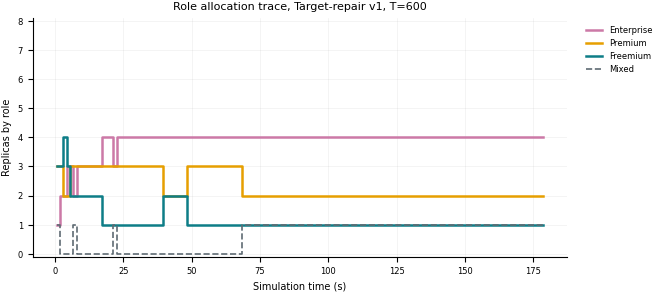

saved figures/selected/scheduler_campaign/target_repair_inversion_trace_global_target_repair_neutral_T600_balanced.pdf


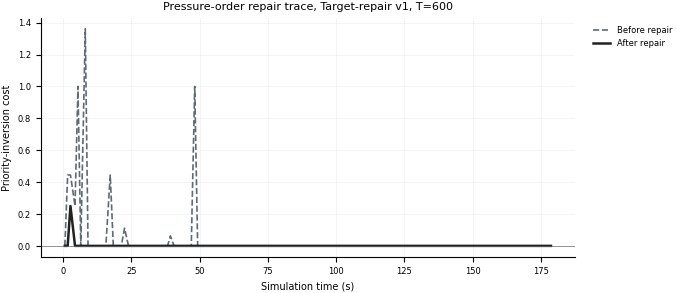

saved figures/selected/scheduler_campaign/target_repair_allocation_trace_global_target_repair_target_only_T600_balanced.pdf


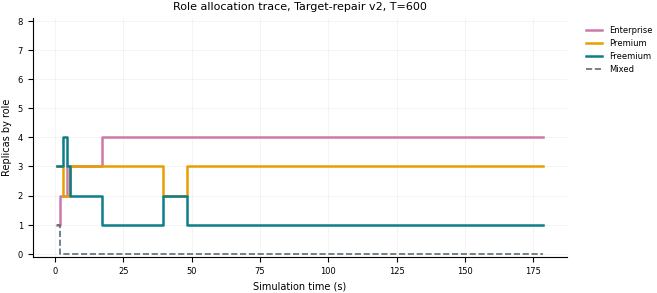

saved figures/selected/scheduler_campaign/target_repair_inversion_trace_global_target_repair_target_only_T600_balanced.pdf


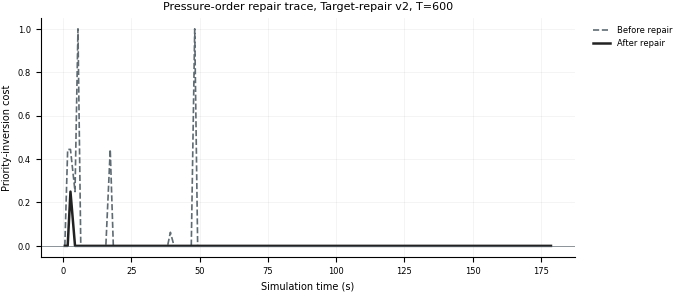

saved figures/selected/scheduler_campaign/target_repair_allocation_trace_global_target_repair_neutral_init_4_2_2_T600_balanced.pdf


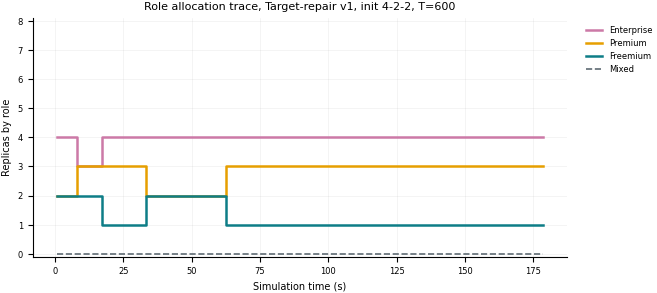

saved figures/selected/scheduler_campaign/target_repair_inversion_trace_global_target_repair_neutral_init_4_2_2_T600_balanced.pdf


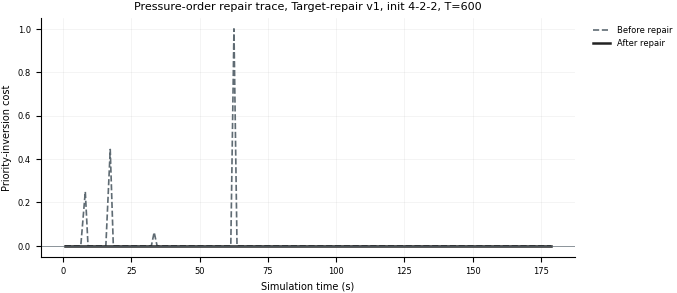

saved figures/selected/scheduler_campaign/target_repair_allocation_trace_global_target_repair_target_only_init_4_2_2_T600_balanced.pdf


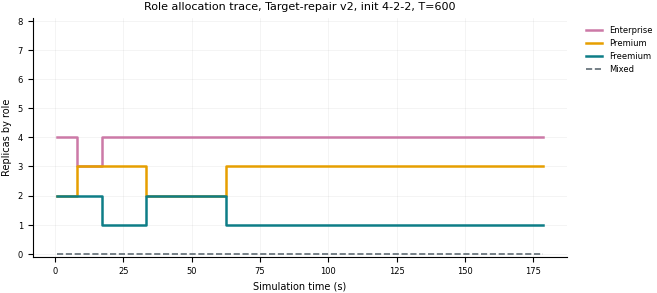

saved figures/selected/scheduler_campaign/target_repair_inversion_trace_global_target_repair_target_only_init_4_2_2_T600_balanced.pdf


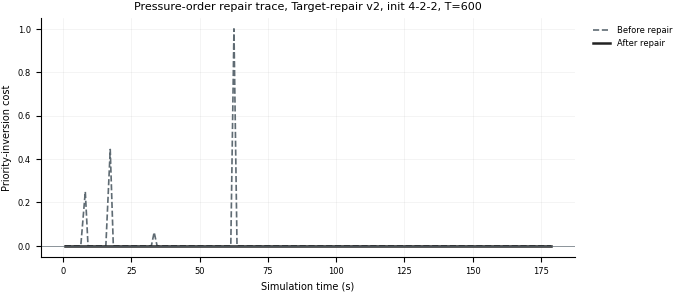

,scheduler,control_epochs,fraction_after_M_positive,mean_after_M,mixed_query_starts,role_moves,priority_repairs,neutral_moves
0,Target-repair v1,144,0.645833,0.645833,0,12,9,3
1,Target-repair v2,144,0.006944,0.006944,0,7,7,0
2,"Target-repair v1, init 4-2-2",144,0.000000,0.000000,0,4,4,0
3,"Target-repair v2, init 4-2-2",144,0.000000,0.000000,0,4,4,0


In [21]:
def read_target_repair_decisions(scheduler, T=600, ratio=SELECTED_RATIO, seed=42):
    path = (
        CAMPAIGN_DIR
        / "K8"
        / f"T{T}"
        / f"ratio_{ratio}"
        / f"seed{seed}"
        / scheduler
        / "target_repair_decisions.csv"
    )
    if not path.exists():
        print("Missing target-repair decisions:", path)
        return pd.DataFrame()
    return pd.read_csv(path)


def plot_target_repair_allocation_trace(scheduler, T=600, ratio=SELECTED_RATIO, seed=42):
    decisions = read_target_repair_decisions(scheduler=scheduler, T=T, ratio=ratio, seed=seed)
    if decisions.empty:
        return

    role_cols = {
        "Enterprise": "after_E",
        "Premium": "after_P",
        "Freemium": "after_F",
        "Mixed": "after_M",
    }

    fig, ax = plt.subplots(figsize=DOUBLE_COL_TALL)
    role_style = {
        "Enterprise": {"color": PALETTE["enterprise"], "linewidth": 1.8},
        "Premium": {"color": PALETTE["premium"], "linewidth": 1.8},
        "Freemium": {"color": PALETTE["freemium"], "linewidth": 1.8},
        "Mixed": {"color": PALETTE["dark_gray"], "linewidth": 1.2, "linestyle": "--"},
    }
    configure_marker_styles(role_style)

    for label, col in role_cols.items():
        ax.step(
            decisions["time"],
            decisions[col],
            where="post",
            label=label,
            **role_style[label],
        )

    ax.set_xlabel("Simulation time (s)")
    ax.set_ylabel("Replicas by role")
    ax.set_title(f"Role allocation trace, {ALGO_LABELS.get(scheduler, scheduler)}, T={T}")
    ax.set_ylim(-0.1, 8.1)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    save_figure(fig, f"target_repair_allocation_trace_{scheduler}_T{T}_{ratio}")
    plt.show()


def plot_target_repair_inversion_trace(scheduler, T=600, ratio=SELECTED_RATIO, seed=42):
    decisions = read_target_repair_decisions(scheduler=scheduler, T=T, ratio=ratio, seed=seed)
    if decisions.empty:
        return

    fig, ax = plt.subplots(figsize=DOUBLE_COL_TALL)
    ax.plot(
        decisions["time"],
        decisions["current_inv"],
        label="Before repair",
        color=PALETTE["dark_gray"],
        linewidth=1.2,
        linestyle="--",
    )
    ax.plot(
        decisions["time"],
        decisions["after_inv"],
        label="After repair",
        color=PALETTE["black"],
        linewidth=1.8,
    )
    ax.axhline(0.0, color=PALETTE["dark_gray"], linewidth=0.7, alpha=0.7)
    ax.set_xlabel("Simulation time (s)")
    ax.set_ylabel("Priority-inversion cost")
    ax.set_title(f"Pressure-order repair trace, {ALGO_LABELS.get(scheduler, scheduler)}, T={T}")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    save_figure(fig, f"target_repair_inversion_trace_{scheduler}_T{T}_{ratio}")
    plt.show()


def target_repair_control_summary(T=600, ratio=SELECTED_RATIO, seed=42):
    rows = []
    for scheduler in ALGO_TARGET_REPAIR:
        decisions = read_target_repair_decisions(scheduler=scheduler, T=T, ratio=ratio, seed=seed)
        if decisions.empty:
            continue
        q_path = (
            CAMPAIGN_DIR
            / "K8"
            / f"T{T}"
            / f"ratio_{ratio}"
            / f"seed{seed}"
            / scheduler
            / "query_events.csv"
        )
        mixed_starts = np.nan
        if q_path.exists():
            queries = pd.read_csv(q_path)
            if "replica_role_at_start" in queries.columns:
                mixed_starts = int((queries["replica_role_at_start"] == "mixed").sum())
        rows.append({
            "scheduler": ALGO_LABELS.get(scheduler, scheduler),
            "control_epochs": len(decisions),
            "fraction_after_M_positive": float((decisions["after_M"] > 0).mean()),
            "mean_after_M": float(decisions["after_M"].mean()),
            "mixed_query_starts": mixed_starts,
            "role_moves": int((decisions["move_from"].fillna("") != "").sum()),
            "priority_repairs": int((decisions["reason"] == "priority_repair").sum()),
            "neutral_moves": int(decisions["reason"].astype(str).str.startswith("neutral_").sum()),
        })
    if rows:
        display(pd.DataFrame(rows))

for scheduler in ALGO_TARGET_REPAIR:
    plot_target_repair_allocation_trace(scheduler=scheduler, T=600)
    plot_target_repair_inversion_trace(scheduler=scheduler, T=600)

target_repair_control_summary(T=600)
